# Дизайн A/B теста: смена верстки объявлений (список - плитка)

**Раздел:** Автозапчасти, Фарпост

## Контекст и постановка задачи

Сейчас объявления в разделе Автозапчасти отображаются **списком**: маленькое
фото слева, текст и цена справа, объявления идут одно под другим.

Планируется переход на **плиточный вид**: крупное фото сверху, название и
цена под ним, несколько карточек в ряд. Изменение запланировано в рамках
общего редизайна Фарпоста на основе качественных исследований (юзабилити-тесты, опросы пользователей, записи сессий из системы веб-аналитики, обращения в тех. поддержку).

(Рандомное предположение с моей стороны )В ходе исследований было замечено: пользователи скроллят список не кликая,
говорят что фото слишком маленькое чтобы понять подходит ли деталь. Это является
источником гипотезы, которую проверяет A/B тест, предполагаем, что качественные исследования дают
направление и уверенность в гипотезе.

Данный ноутбук описывает следующие задачи:

1. **Дизайн теста**:гипотеза, метрики, рандомизация, размер выборки, длительность
2. **Способы оценки результата**: анализ данных, статистические тесты, выводы

Анализ выполняется на синтетических данных (генерация в `generate_data.py`, сам датасет - `farpost.raw_events`), в которые
заложен реальный эффект +12% к CTR для тестовой группы treatment (в рамках 1 сессии) при Минимально обнаружимом эффекте +5% (Расчет MDE представлен в разделе 4, реальный эффект взяли просто экспертно и выше MDE для симуляции успеха теста)

## Настройка окружения

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import (chisquare, chi2_contingency)
from statsmodels.stats.proportion import (
    proportions_ztest,
    confint_proportions_2indep,
    proportion_confint,
)
import clickhouse_connect
from dotenv import load_dotenv

load_dotenv()

pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## 1. Гипотеза

**H0 (нулевая гипотеза):** переход на плиточный вид не влияет на CTR
(`CTR_treatment = CTR_control`)

**H1 (альтернативная гипотеза):** переход на плиточный вид влияет на CTR
(`CTR_treatment ≠ CTR_control`)

Тест двусторонний, не исключаем что плитка 
может навредить пользовательскому навредить пользовательскому опыту.
Двусторонний тест защищает от того, чтобы пропустить негативный эффект.  
Двусторонний тест требует больший размер выборки, исходя их высокого трафика 300к DAU, мы можем его себе позволить

## 2. Метрики

### Первичная метрика — CTR (Конверсия в клики)

`CTR = listing_click / page_view`

Помогает ли плитка с крупными фото
принять решение о клике.

### Гардрейл (балансирующая) метрика — Contact rate (конверсия из объявления в контакт с продавцом) среди кликнувших

`contact_rate = contact_seller / listing_click`

Защита от эффекта новизы: пользователи могут кликать чаще просто из
интереса к новому интерфейсу, исследуя его, без реального намерения купить
деталь. Если CTR растёт, а доля реальных обращений к продавцу среди кликнувших
падает - это может быть сигналом о том, что дополнительные клики не несут ценности для бизнеса.

Решение о запуске принимается по первичной метрике, но только если гардрейл
не деградировал.

## 3. Юнит рандомизации и схема назначения групп

**Рандомизация по пользователю, а не по сессии.** Если рандомизировать по
сессии, один и тот же человек может в разных визитах увидеть то список, то
плитку - это ломает независимость наблюдений и искажает результат.

Схема назначения в группы:

| Тип пользователя | Идентификатор | Участвует в тесте |
|---|---|---|
| Зарегистрированный | `user_id` | Да |
| Незарегистрированный с cookie | `cookie_id` | Да |
| Анонимный (нет стабильного ID) | — | Нет, видит дефолтный вид (список) |

**Важное допущение** - В текущей симуляции я сделал допущение, что cookie не сбрасывается и таким образом мы всегда можем явно идентифицировать пользователя, но в реальном продакшене это может быть ненадежный подход, есть вариант идентифицировать по связке cookie + fingerprint_id, который я нагенерил в синтетическом датасете, но фактически не использовал для упрощения.

Анонимные пользователи (нет ни cookie, ни явного user_id пользоватеоя) исключены из теста
полностью — для них нет способа гарантировать стабильность группы между
сессиями. 

В продакшене допускается исследование только по зарегистрированным пользователям, чтобы избежать любых искажений, связанных с показом разных версий одному человеку, тем более с учетом достаточного количества трафика (DAU - 300к). В рамках симуляции оставляем и зареганных, и нет, т.к. выдвигаем гипотезу о том, что зареганные пользователя заведомо "лояльны" и они в любом случае будут кликать и доходить до контакта с продавцом независимо от верстки. (получили эти данные из гипотетического качественного исследования среди зарегистрированных пользователей, в разделе 6.7 представлено дополнительное исследование вне основного A/B теста и не влияющее на его интерпретацию )

Сплит 50/50 - математически оптимален, минимизирует суммарный размер
необходимой выборки при сравнении двух групп, самый распространенный

## 4. Расчёт размера выборки и описание зависимых параметров

Параметры теста и их обоснование:

- **α = 0.05** - стандартный уровень значимости, вероятность ложно обнаружить
  эффект, которого нет (ошибка 1 рода)
- **Мощность = 0.90**  выше дефолтных 80%, потому что решение о редизайне
  дорогое и стратегическое (предположение): важнее не пропустить реальный эффект, чем сэкономить
  на размере выборки. При нашем трафике (300k DAU на раздел) повышенная мощность
  практически не увеличивает длительность теста. 
- **Baseline CTR = 0.35** - текущий уровень CTR в разделе Автозапчасти (просто рандом число, предположение)
- **MDE = +5% CTR, т.е. + 1,75 п.п. = 36,75 СTR %  (минимальный эффект который оправдывает редизайн)** - какой минимальный прирост
  CTR покрывает стоимость разработки. Логика обоснования: считаем стоимость
  редизайна в человеко-часах, считаем сколько дополнительных кликов/контактов
  с продавцом даёт каждый процент прироста CTR при текущем трафике, и какой
  срок окупаемости приемлем. Подробнее - далее.

Все цифры взял примерные, рандомно.  
Допустим мы считаем, что приемлемый срок окупаемости редизайна - 3 месяца  
Стоимость редизайна = 200 часов * 3000 руб/час = 600000 руб  
Текущий CTR = 35%, трафик = 300000 DAU  
Кликов в день сейчас = 300000 * 0.35 = 105,000  
Конверсия клик - контакт с продавцом = 18%  
Доход с одного контакта = 10 руб  
Доп. клики в день = 300000 * 0.0175 = 5250  - здесь заложили +5% MDE
Доп. контакты в день = 5250 * 0.18 = 945  
Доп. выручка в день = 945 * 10 = 9450 руб  

Срок окупаемости = 600000 / 9450 ≈ 63 дня (~2 месяца). Получаем, что при +5% CTR срок окупаемости удовлетворяет требованиям бизнеса

In [2]:
def required_sample_size(baseline_rate, mde_relative, alpha=0.05, power=0.90):
    """
    Считает минимальный размер выборки на группу для теста двух пропорций.

    Args:
        baseline_rate: базовый уровень метрики в контрольной группе (например CTR)
        mde_relative: минимальный детектируемый эффект +5%
        alpha: уровень значимости (вероятность ошибки 1 рода)
        power: статистическая мощность (1 - вероятность ошибки 2 рода)

    Returns:
        Минимальное количество пользователей на одну группу
    """
    z_alpha = stats.norm.ppf(1 - alpha / 2) # делим альфу на 2, т.к. двусторонний тест
    z_beta = stats.norm.ppf(power)

    mde_absolute = baseline_rate * mde_relative
    p = baseline_rate

    n = 2 * (z_alpha + z_beta) ** 2 * p * (1 - p) / mde_absolute ** 2
    return int(np.ceil(n))


BASELINE_CTR = 0.35
MDE_RELATIVE = 0.05
ALPHA = 0.05
POWER = 0.90

n_per_group = required_sample_size(BASELINE_CTR, MDE_RELATIVE, ALPHA, POWER)

print(f'Baseline CTR: {BASELINE_CTR}')
print(f'MDE (относительный): {MDE_RELATIVE:.0%}')
print(f'Альфа: {ALPHA}, Мощность: {POWER:.0%}')
print(f'\nНужно пользователей на группу: {n_per_group:,}')
print(f'Всего на тест: {n_per_group * 2:,}')

Baseline CTR: 0.35
MDE (относительный): 5%
Альфа: 0.05, Мощность: 90%

Нужно пользователей на группу: 15,612
Всего на тест: 31,224


Требуется 31к человек для теста. У нас их с запасом даже при скейлинге * 0.1 от реального трафика 300к DAU (описан в скрипте `generate_data.py`) - 341к.  
Тем не менее, продолжительность теста выбираем исходя из других параметров, об этом дальше

## 5. Длительность теста

Проверим сколько календарных дней нужно математически, учитывая наш трафик.

In [5]:
DAU_PER_SECTION = 30000   # реальный трафик раздела (по данным от команды) со скейлингом * 0.1
SHARE_TRACKABLE = 0.80      # доля пользователей с user_id или cookie_id (не анонимы), это константа задана в generate_data.py
SPLIT = 0.5                 # доля одной группы

daily_users_per_group = DAU_PER_SECTION * SHARE_TRACKABLE * SPLIT
days_needed_math = n_per_group / daily_users_per_group

print(f'Пользователей в группу в день: {daily_users_per_group:,.0f}')
print(f'Математически достаточно дней: {days_needed_math:.2f}')

Пользователей в группу в день: 12,000
Математически достаточно дней: 1.30


Математически выборка набирается за два неполных дня. Но длительность теста
расширяем до **4 полных недель** по двум причинам, не связанным с размером
выборки:

**День недели.** Поведение пользователей в будни и выходные отличается
(в выходные трафик на ~20-30% выше - предположение). Тест должен захватывать целое число
полных недель, иначе одна группа может случайно получить больше выходного
трафика чем другая. 4 недели с понедельника по понедельник

**Эффект новизны** Новый интерфейс первое время привлекает внимание просто
потому что он новый, а не потому что объективно лучше. Этот эффект обычно
затухает за 1-2 недели. Беря 4 недели вместо минимальных 2, мы получаем запас
и можем сравнить поведение в первую и последнюю недели теста, чтобы убедиться
что эффект стабилен, а не угасающий артефакт новизны.

**Итоговый период теста: 30 марта - 27 апреля 2026 (4 полные недели).**

**Важное допущение**: перед запуском реального теста стоит провести
**AA-тест** - разделить пользователей на две группы без реального изменения
интерфейса и убедиться что метрики статистически не отличаются. Если отличие
находится - рандомизация работает некорректно, и это нужно исправить до
запуска настоящего A/B теста. В рамках текущего ноутбука мы не проводим, потому что и до, и во время, и после A/B теста сгенерированы постфактум

## 6. Способы оценки результата

План анализа:

1. Загрузка данных из витрины `mart_ab_test`
2. Проверка качества рандомизации (SRM-тест)
3. Проверка баланса групп по демографическим атрибутам
4. Статистический тест по первичной метрике (CTR)
5. Статистический тест по гардрейл метрике (contact rate)
6. Визуализация результатов
7. Сегментный анализ постфактум
8. Итоговый вывод и рекомендация

### 6.1 Загрузка данных

In [6]:
client = clickhouse_connect.get_client(
    host=os.getenv('CLICKHOUSE_HOST'),
    port=int(os.getenv('CLICKHOUSE_PORT', 8123)),
    username=os.getenv('CLICKHOUSE_USER'),
    password=os.getenv('CLICKHOUSE_PASSWORD'),
    database=os.getenv('CLICKHOUSE_DATABASE', 'farpost'),
)

df = client.query_df('SELECT * FROM farpost.mart_ab_test')
print(f'Загружено строк: {len(df):,}')
df.head()

Загружено строк: 341,078


,analysis_id,experiment_group,is_registered,user_type,device_type,os,region,had_click,had_contact,n_page_views,n_clicks,n_contacts
0,b'00001db3-2a85-4099-a8b3-133b83da17f0',treatment,1,registered,desktop,macOS,Приморский край,0,0,2,0,0
1,b'00003596-cc3c-4aa9-9e58-dac893579d3c',control,0,cookie,desktop,Windows,Приморский край,1,0,3,3,0
2,b'0000598c-f7f0-4615-8739-a9983395cde1',treatment,0,cookie,mobile,Android,Приморский край,1,0,1,1,0
3,b'0000f286-825b-4c5f-9e40-27c347fd1825',treatment,0,cookie,desktop,macOS,Приморский край,0,0,3,0,0
4,b'00011212-4880-43b3-b4da-be4c5a6d2910',control,1,registered,mobile,Android,Приморский край,1,1,1,1,1


### 6.2 Проверка качества рандомизации (SRM)

(SRM) - проверка, что фактическое соотношение
размеров групп соответствует заданному (50/50). Если соотношение значимо
отличается - рандомизация сломана (например из-за бага в коде распределения
или из-за того что один из вариантов интерфейса технически чаще не
прогружается), и результатам теста доверять нельзя независимо от того что
покажут метрики.

In [ ]:
group_counts = df['experiment_group'].value_counts()
print(group_counts)

observed = group_counts.values
expected = [observed.sum() / 2] * 2 # делим на 2, т.к. сплит 50/50

chi2, p_value_srm = chisquare(observed, expected)
print(f'\nТест Хи-квадрат: {chi2:.4f}, p-value: {p_value_srm:.4f}')

if p_value_srm < 0.05:
    print('SRM обнаружен - распределение групп статистически отличается от 50/50.')
    print('Результаты теста ниже нужно интерпретировать с осторожностью.')
else:
    print('SRM не обнаружен - рандомизация работает корректно.')

experiment_group
control      170692
treatment    170386
Name: count, dtype: Int64

Тест Хи-квадрат: 0.2745, p-value: 0.6003
SRM не обнаружен - рандомизация работает корректно.


### 6.3 Баланс групп по демографическим атрибутам

Проверяем, что распределение пользователей по устройству, региону и типу
регистрации похоже в обеих группах. Если группы систематически отличаются по
составу - это ещё один признак проблем с рандомизацией.

In [12]:
for col in ['device_type', 'region', 'is_registered', 'user_type']:
    print(f'\n{col}:')
    print(pd.crosstab(df['experiment_group'], df[col], normalize='index').round(3))


for col in ['device_type', 'region', 'is_registered', 'user_type']:
    contingency = pd.crosstab(df['experiment_group'], df[col])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    status = 'баланс в норме' if p_value > 0.05 else 'возможен дисбаланс'
    print(f'{col}: p-value = {p_value:.4f} — {status}')


device_type:
device_type       desktop  mobile
experiment_group                 
control            0.4500  0.5500
treatment          0.4510  0.5490

region:
region            Приморский край  Хабаровский край
experiment_group                                   
control                    0.6200            0.3800
treatment                  0.6210            0.3790

is_registered:
is_registered         0      1
experiment_group              
control          0.5630 0.4370
treatment        0.5620 0.4380

user_type:
user_type         cookie  registered
experiment_group                    
control           0.5630      0.4370
treatment         0.5620      0.4380
device_type: p-value = 0.8583 — баланс в норме
region: p-value = 0.5698 — баланс в норме
is_registered: p-value = 0.3981 — баланс в норме
user_type: p-value = 0.3981 — баланс в норме


Распределения в контрольной и тестовой группах близятся к равным по всем демографическим параметрам. Статистически значимые отклонения не обнаружены.

### 6.4 Первичная метрика - CTR

Z-тест для двух пропорций: сравниваем долю пользователей с кликом в группе
control и в группе treatment.  
Если бы у нас были бы огромные данные на миллиарды наблюдений или данные были бы сильно скошены, можно было бы применять бакетный подход (партиционировать пользователей по бакетам, посчитать средний CTR в каждом из них) и потом применить t-test на эти значения, т.к. распределения средних значений из множества подвыборок стремились бы к нормальному распределению согласно ЦПТ  

In [14]:
control = df[df['experiment_group'] == 'control']
treatment = df[df['experiment_group'] == 'treatment']

n_control, n_treatment = len(control), len(treatment)
clicks_control = control['had_click'].sum()
clicks_treatment = treatment['had_click'].sum()

ctr_control = clicks_control / n_control
ctr_treatment = clicks_treatment / n_treatment

stat, p_value = proportions_ztest(
    [clicks_treatment, clicks_control],
    [n_treatment, n_control]
)

ci_low, ci_high = confint_proportions_2indep(
    clicks_treatment, n_treatment,
    clicks_control, n_control,
    method='wald'
)

print(f'Control:   CTR = {ctr_control:.4f}  ({clicks_control} / {n_control})')
print(f'Treatment: CTR = {ctr_treatment:.4f}  ({clicks_treatment} / {n_treatment})')
print(f'\nОтносительный лифт: {(ctr_treatment / ctr_control - 1) * 100:.2f}%')
print(f'Z-статистика: {stat:.4f}')
print(f'p-value: {p_value:.6f}')
print(f'95% доверительный интервал разницы (treatment - control): [{ci_low:.4f}, {ci_high:.4f}]')

if p_value < 0.05:
    print('\nРезультат статистически значим: эффект от плитки на CTR обнаружен.')
else:
    print('\nРезультат статистически не значим на уровне α = 0.05.')

Control:   CTR = 0.5318  (90781 / 170692)
Treatment: CTR = 0.5803  (98877 / 170386)

Относительный лифт: 9.11%
Z-статистика: 28.4874
p-value: 0.000000
95% доверительный интервал разницы (treatment - control): [0.0451, 0.0518]

Результат статистически значим: эффект от плитки на CTR обнаружен.


Относительный лифт +9% отличается от заложенного +12%, т.к. +9% считается на уровне пользователя, а +12% на уровне сессии. Т.к. тестируемая метрика обозначает "заходил хотя бы раз за время A/B теста", то итоговое значение вероятности пересчитывается по другой формуле 1 - (1-p)^k. Это не является ошибкой или багом.

### 6.5 Гардрейл метрика - Contact rate среди кликнувших

Считаем долю контактов с продавцом именно среди тех кто кликнул по
объявлению - это показывает, конвертируются ли дополнительные клики
treatment-группы в реальный интерес, или они "пустые" (артефакт новизны
интерфейса).

In [15]:
control_clickers = control[control['had_click'] == 1]
treatment_clickers = treatment[treatment['had_click'] == 1]

n_control_clickers = len(control_clickers)
n_treatment_clickers = len(treatment_clickers)

contacts_control = control_clickers['had_contact'].sum()
contacts_treatment = treatment_clickers['had_contact'].sum()

contact_rate_control = contacts_control / n_control_clickers
contact_rate_treatment = contacts_treatment / n_treatment_clickers

stat_g, p_value_g = proportions_ztest(
    [contacts_treatment, contacts_control],
    [n_treatment_clickers, n_control_clickers]
)

print(f'Control:   contact rate среди кликнувших = {contact_rate_control:.4f}')
print(f'Treatment: contact rate среди кликнувших = {contact_rate_treatment:.4f}')
print(f'\np-value: {p_value_g:.6f}')

if p_value_g < 0.05 and contact_rate_treatment < contact_rate_control:
    print('\nГардрейл нарушен: доля контактов среди кликнувших значимо упала.')
    print('Возможен эффект новизны - дополнительные клики не конвертируются в реальный интерес.')
else:
    print('\nГардрейл в норме: качество кликов не упало.')

Control:   contact rate среди кликнувших = 0.2233
Treatment: contact rate среди кликнувших = 0.2355

p-value: 0.000000

Гардрейл в норме: качество кликов не упало.


### 6.6 Визуализация

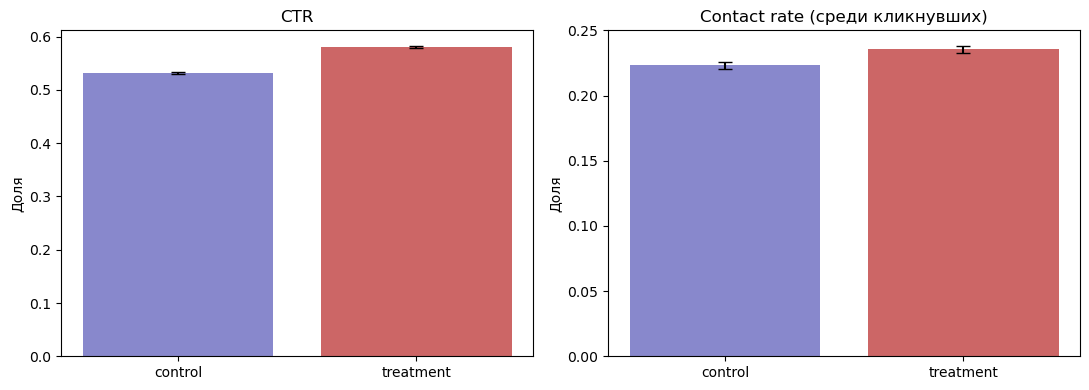

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

metrics = [
    ('CTR', ctr_control, ctr_treatment, clicks_control, n_control, clicks_treatment, n_treatment),
    ('Contact rate (среди кликнувших)', contact_rate_control, contact_rate_treatment,
     contacts_control, n_control_clickers, contacts_treatment, n_treatment_clickers),
]

for ax, (title, v_c, v_t, k_c, n_c, k_t, n_t) in zip(axes, metrics):
    ci_c = proportion_confint(k_c, n_c, method='wilson')
    ci_t = proportion_confint(k_t, n_t, method='wilson')

    values = [v_c, v_t]
    errors = [
        [v_c - ci_c[0], v_t - ci_t[0]],
        [ci_c[1] - v_c, ci_t[1] - v_t],
    ]

    ax.bar(['control', 'treatment'], values, yerr=errors, capsize=5, color=['#8888cc', '#cc6666'])
    ax.set_title(title)
    ax.set_ylabel('Доля')

plt.tight_layout()
plt.show()

### 6.7 Сегментный анализ (постфактум)

Этот анализ не используется для принятия решения по тесту - он проводится
постфактум, после получения основного результата, чтобы понять неоднородность
эффекта по сегментам. Выдвигать новые гипотезы после просмотра нельзя и
выдавать их за подтверждённые тестом, т.к. эта манипуляция анализом данных

Гипотеза для проверки: эффект может быть сильнее у незарегистрированных
пользователей, т.к. зарегестрированные "лояльны" и в любом случае нацелены дойти до контакта с продавцом независимо от верстки 

In [17]:
def segment_ctr_table(df, segment_col):
    """
    Считает CTR по группам в разрезе сегмента.

    Используется для постфактум-анализа неоднородности эффекта,
    не для принятия решения по тесту.
    """
    table = (
        df.groupby([segment_col, 'experiment_group'])['had_click']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'ctr', 'count': 'n'})
        .reset_index()
    )
    return table


for col in ['is_registered', 'device_type']:
    print(f'\nCTR по группам в разрезе {col}:')
    print(segment_ctr_table(df, col).round(4))


CTR по группам в разрезе is_registered:
   is_registered experiment_group    ctr      n
0              0          control 0.5329  96167
1              0        treatment 0.5802  95749
2              1          control 0.5305  74525
3              1        treatment 0.5805  74637

CTR по группам в разрезе device_type:
  device_type experiment_group    ctr      n
0     desktop          control 0.5299  76884
1     desktop        treatment 0.5777  76799
2      mobile          control 0.5334  93808
3      mobile        treatment 0.5825  93587


Значительной разницы в эффекте по сегментам не обнаружено. Это связано с особенностями архитектуры генерации синтетичских данных.

## 7. Итоговый вывод и рекомендация

**Первичная метрика CTR статистически значима и положительна + гардрейл Contact Rate не деградировал + практическая значимость подтверждена (рост CTR на 9% оправдывает затраты на редизайн)**   
**Рекомендация**: выкатывать плиточный вид на 100% трафика. 